# Complementaria Semana 3: Teorema del Límite Central

La semana pasada estimamos por simulación la distribución, la media y la varianza de $M = \max(D_1, D_2)$, y vimos que los resultados no coincidían exactamente con la teoría. Quedó una pregunta abierta: **¿qué tan lejos puede estar una estimación hecha por simulación?**

El **Teorema del Límite Central (TLC)** es la herramienta que responde eso. Hoy lo validamos empíricamente y lo usamos para ponerle una medida de incertidumbre a los resultados de una simulación.

### Objetivos

1. Construir promedios muestrales y verificar empíricamente que se aproximan a una Normal.
2. Estandarizar y comprobar que $Z \approx \mathcal{N}(0,1)$.
3. Construir **intervalos de confianza** para una estimación de simulación, y entender qué significan.
4. Ver que el TLC funciona sin importar la distribución de partida, y que su calidad **sí** depende de ella.

> Esto es la base de todo lo que viene después en el curso: cada vez que reportemos un resultado de simulación —un tiempo de espera, una utilización— vamos a necesitar decir qué tan preciso es.

## 0. Preparación

Este notebook se trabaja en **VS Code**, sobre el ambiente virtual de los tutoriales de la semana 1. Si te falta alguna librería, descomenta la primera línea.

In [1]:
# %pip install numpy matplotlib scipy

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

## 1. Retomamos el ejercicio de los dados

Seguimos con $M = \max(D_1, D_2)$ de la complementaria pasada, pero ahora la variable de interés no es $M$ sino su **promedio**.

Tomaremos muchos promedios de $M=\max(D_1,D_2)$. Aunque $M$ no es Normal, el **promedio** de $k$ réplicas independientes se aproxima a Normal cuando $k$ es suficientemente grande. Se suele citar $k \ge 30$ como regla de dedo, pero **no es un número mágico**: qué tan grande debe ser $k$ depende de la asimetría de la distribución original. En la sección 3 lo veremos con $k = 5, 30$ y $100$.

Definimos el promedio:

$$
\bar M_k \;=\; \frac{1}{k}\sum_{j=1}^{k} M_j
$$

Parámetros teóricos de $M$ con pmf $p(m)=\tfrac{2m-1}{36}$ para $m=1,\dots,6$:

$$
\mu \;=\; \sum_{m=1}^{6} m\,p(m),
\qquad
\mathbb{E}[M^2] \;=\; \sum_{m=1}^{6} m^2\,p(m),
\qquad
\sigma^2 \;=\; \mathbb{E}[M^2]-\mu^2.
$$

Para el promedio de $k$ observaciones i.i.d.:

$$
\mathbb{E}[\bar M_k] \;=\; \mu,
\qquad
\mathrm{Var}(\bar M_k) \;=\; \frac{\sigma^2}{k},
\qquad
\mathrm{SE}(\bar M_k) \;=\; \frac{\sigma}{\sqrt{k}}.
$$

Estandarización y forma límite (TLC):

$$
Z_k \;=\; \frac{\bar M_k - \mu}{\sigma/\sqrt{k}}
\;\;\approx\;\; \mathcal{N}(0,1)
\quad \text{cuando } k \text{ es grande.}
$$

Intervalo de confianza del 95 % para la media con $\sigma$ desconocida (sustituyendo $s$ por $\sigma$):

$$
\bar M_k \;\pm\; 1.96\,\frac{s}{\sqrt{k}}
\qquad\text{(para } k \text{ grande; en muestras pequeñas usar } t_{0.975,\,k-1}\text{)}
$$

Ideas prácticas:
- Aumentar $k$ reduce la variabilidad del promedio: el error estándar cae como $1/\sqrt{k}$.
- Para visualizar el TLC, grafica el histograma de $Z_k$ y un QQ-plot contra la Normal estándar; deberían verse cercanos a $\mathcal N(0,1)$.

### 1.1 Simulación de la variable aleatoria base

La variable de interés es $M = \max(D_1, D_2)$, donde $D_1$ y $D_2$ son lanzamientos independientes de dos dados justos. Fijamos la semilla del generador para garantizar reproducibilidad, y definimos el soporte de $M$ (los valores $1,\dots,6$) que usaremos para calcular sus parámetros teóricos.

In [2]:
rng = np.random.default_rng(0)   # generador con semilla (reproducible)
m   = np.arange(1, 7)            # soporte de M: valores posibles 1..6

### 1.2 Construcción de promedios muestrales

Para analizar empíricamente el comportamiento de la media muestral, se construyen
réplicas independientes. Cada réplica consiste en $k$ observaciones de la variable
$M$, a partir de las cuales se calcula un promedio.
El número total de réplicas se denota por `reps`.


In [3]:
k    = 30      # tamaño del promedio (cuántos datos se promedian DENTRO de cada réplica)
reps = 20000   # número de réplicas (cuántos promedios se calculan)

# 1) simulación de los dos dados: una matriz (reps, k) -> cada fila es UNA réplica
rolls1 = rng.integers(1, 7, size=(reps, k))
rolls2 = rng.integers(1, 7, size=(reps, k))
Mmat   = np.maximum(rolls1, rolls2)

# 2) promedio y desviación estándar DENTRO de cada réplica
means = Mmat.mean(axis=1)
sds   = Mmat.std(axis=1, ddof=1)

### 1.3 Parámetros teóricos de la variable aleatoria

Con el fin de aplicar el Teorema del Límite Central, se calculan los parámetros
teóricos de la variable aleatoria $M$, utilizando su función de probabilidad:

$$
\mathbb{P}(M = m) = \frac{2m - 1}{36}, \quad m = 1, \dots, 6.
$$


In [4]:
# 4) parámetros teóricos de M (pmf: (2m-1)/36)
mu   = (m * ((2*m - 1)/36)).sum()          # E[M]
Ex2  = ((m**2) * ((2*m - 1)/36)).sum()     # E[M^2]
sigma = np.sqrt(Ex2 - mu**2)               # SD(M)



### 1.4 Aplicación del Teorema del Límite Central

A continuación, se estandarizan los promedios muestrales utilizando la expresión
del Teorema del Límite Central:

$$
Z = \frac{\bar{M} - \mu}{\sigma / \sqrt{k}}.
$$

Bajo este resultado teórico, la variable $Z$ debería aproximarse a una
distribución normal estándar cuando el tamaño de muestra $k$ es suficientemente grande.


In [5]:
# 5) estandarización de los promedios: Z = (mean - mu) / (sigma / sqrt(k))
z = (means - mu) / (sigma/np.sqrt(k))

print("Media de z:", z.mean(), "  Desv. Estándar de z:", z.std(ddof=1))
# análisis: z ~ Normal(0,1) -> media ~ 0 y sd ~ 1



Media de z: 0.0136380696018807   Desv. Estándar de z: 0.9973735563051509


### 1.5 Intervalo de confianza para la esperanza de $M$

Aquí está la utilidad práctica del TLC: nos permite ponerle una **medida de incertidumbre** a una estimación hecha por simulación.

Con **una sola** muestra de $k$ observaciones no conocemos $E[M]$, pero sí podemos construir un intervalo que la contenga con alta probabilidad:

$$
\bar{M} \;\pm\; t_{0.975,\,k-1}\,\frac{s}{\sqrt{k}}
$$

donde $s$ es la desviación estándar **de esa muestra**. Usamos $t$ en lugar de $z$ porque $\sigma$ es desconocida y $k=30$ no es enorme.

In [6]:
# Parámetro teórico exacto (solo lo conocemos porque este ejemplo es de juguete)
mu_real = mu

# --- IC a partir de UNA sola réplica de k = 30 observaciones ---
t_crit = stats.t.ppf(0.975, k - 1)
lo = means[0] - t_crit * sds[0]/np.sqrt(k)
hi = means[0] + t_crit * sds[0]/np.sqrt(k)

print(f"Réplica 1:  media = {means[0]:.4f},  s = {sds[0]:.4f}")
print(f"IC 95% para E[M]: ({lo:.4f}, {hi:.4f})   ancho = {hi-lo:.4f}")
print(f"¿Contiene el valor real mu = {mu_real:.4f}?  {lo <= mu_real <= hi}")

IC 95% para E[M]: (4.4722, 4.4793)


#### ¿Qué significa realmente "95% de confianza"?

No significa que $E[M]$ esté dentro de *ese* intervalo con probabilidad 0.95: $E[M]$ es un número fijo, está o no está. Lo que significa es que **si repitiéramos el experimento muchas veces, el 95% de los intervalos construidos así contendrían el valor real**.

Como tenemos 20.000 réplicas, podemos comprobarlo directamente:

In [ ]:
# Construimos el IC de CADA una de las 20.000 réplicas y contamos cuántos contienen mu
lo_todos = means - t_crit * sds/np.sqrt(k)
hi_todos = means + t_crit * sds/np.sqrt(k)

cobertura = np.mean((lo_todos <= mu_real) & (mu_real <= hi_todos))

print(f"Intervalos construidos : {reps}")
print(f"Ancho promedio         : {np.mean(hi_todos - lo_todos):.4f}")
print(f"Cobertura empírica     : {cobertura:.4f}   (nominal: 0.95)")

# ¿Y si usáramos z = 1.96 en vez de t, ignorando que sigma es desconocida?
lo_z = means - 1.96 * sds/np.sqrt(k)
hi_z = means + 1.96 * sds/np.sqrt(k)
print(f"Cobertura usando z=1.96: {np.mean((lo_z <= mu_real) & (mu_real <= hi_z)):.4f}")

Dos cosas para notar en el resultado:

1. La cobertura da **cerca** del 95%, pero no exactamente. Con $z=1.96$ queda alrededor del **93.7%**, y con $t_{0.975,29}$ sube a **~94.5%**. El TLC es una **aproximación**: con $k=30$ y una variable asimétrica como $M$, todavía no es perfecta. Un intervalo "del 95%" que en realidad cubre el 93.7% es justo el tipo de detalle que importa cuando se reportan resultados de simulación.
2. Usar $t$ en vez de $z$ mejora la cobertura, porque el intervalo se ensancha para compensar que $\sigma$ fue estimada a partir de los datos.

> Compara este intervalo (ancho $\approx 1.0$) con lo que pasaría si promediáramos las 600.000 observaciones de golpe: el ancho caería a $\approx 0.007$. Más datos dan más precisión, pero el intervalo de **una** réplica es el que refleja la incertidumbre real de un estudio de simulación de tamaño $k$.

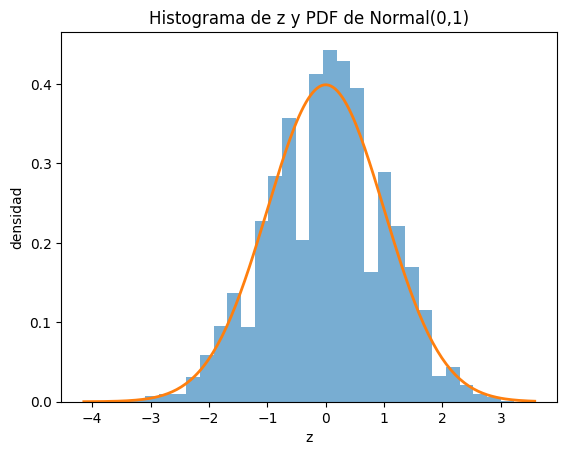

In [7]:
# Visualización del TLC: histograma de z contra la pdf de N(0,1)
plt.hist(z, bins=30, density=True, alpha=0.60)   # histograma de z
xmin, xmax = plt.xlim()                         # límites del eje x para trazar la pdf
x = np.linspace(xmin, xmax, 200)                # malla para la curva teórica
p = norm.pdf(x, 0, 1)                           # pdf de N(0,1)
plt.plot(x, p, linewidth=2)                     # curva teórica sobre el histograma
plt.title("Histograma de z y PDF de Normal(0,1)")
plt.xlabel("z")
plt.ylabel("densidad")
plt.show()

## 2. Ejemplo de aplicación en Ingeniería

La empresa **ProdServ** tiene una planta de ensamblaje cuya inspección de calidad se hace por muestreo: de cada lote de tamaño fijo se mide la fracción de piezas no conformes y, si supera un umbral, se activa reproceso.

La dirección de operaciones quiere fijar estándares de calidad, pero la fracción de no conformes **fluctúa lote a lote** por la variabilidad propia del proceso. La pregunta es entonces: si promediamos varios lotes, ¿qué tan confiable es ese promedio y cuánta incertidumbre le queda?

Es exactamente el problema de la sección 1, ahora con una variable distinta.

### 2.1 Proporción de no conformes por lote

Cada lote tiene tamaño $n = 50$ y cada pieza es no conforme con probabilidad $p = 0.10$.

Usaremos **simulación Monte Carlo** con `reps = 20000` réplicas de tamaño `k = 30` para generar los datos, estandarizar los promedios, verificar el TLC y construir un intervalo de confianza.

Cada lote tiene tamaño $n$. El número de no conformes $B \sim \text{Binomial}(n, p)$.  
Proporción por lote $Y = B/n$.  
Para cada réplica, promediamos $k$ lotes: $\bar Y_k = \frac{1}{k}\sum_{j=1}^k Y_j$.

Teoría: $\mathbb E[Y]=p$, $\mathrm{Var}(Y) = \dfrac{p(1-p)}{n}$.  

Por el TLC, la estandarización

$$
Z \;=\; \frac{\bar Y_k - p}{\sqrt{p(1-p)/(n\,k)}}
$$

debería lucir aproximadamente $\mathcal N(0,1)$ si $n$ y $k$ son razonables y $p$ no es extremo.

A.2 Proporciones TLC
mean(z) ~ 0.0010672220776235888   sd(z) ~ 0.9970079531158527
IC 95% para E[Y]: (0.0999, 0.1001)   (teórico p=0.1)


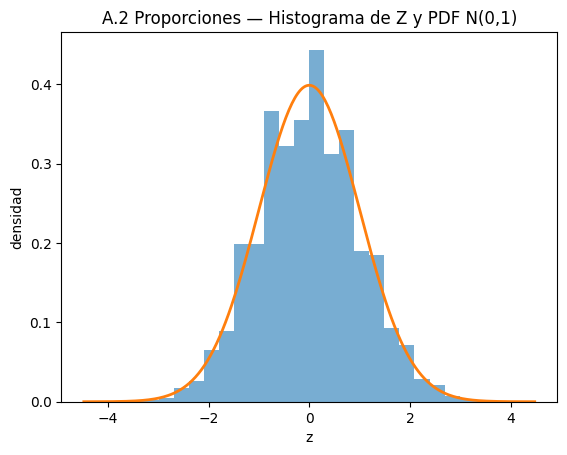

In [8]:
# 0) Parámetros y configuración
rng_b = np.random.default_rng(1)
p     = 0.10    # probabilidad de que una pieza sea no conforme
n     = 50      # tamaño de lote
k     = 30      # lotes promediados POR réplica
reps  = 20000   # número de réplicas

# 1) Simulación: B ~ Bin(n, p) por lote, y proporción por lote Y = B/n
B = rng_b.binomial(n=n, p=p, size=(reps, k))
Y = B / n

# 2) Promedio y desviación estándar DENTRO de cada réplica
means_Y = Y.mean(axis=1)
sds_Y   = Y.std(axis=1, ddof=1)

# 3) Estandarización por TLC con los parámetros teóricos
z_Y = (means_Y - p) / np.sqrt(p*(1-p)/(n*k))
print(f"mean(z) = {z_Y.mean():.4f}   sd(z) = {z_Y.std(ddof=1):.4f}    (esperado: 0 y 1)")

# 4) IC 95% a partir de UNA réplica, igual que en la sección 1
t_crit_Y = stats.t.ppf(0.975, k - 1)
lo = means_Y[0] - t_crit_Y * sds_Y[0]/np.sqrt(k)
hi = means_Y[0] + t_crit_Y * sds_Y[0]/np.sqrt(k)
print(f"\nRéplica 1: proporción promedio = {means_Y[0]:.4f}")
print(f"IC 95% para E[Y]: ({lo:.4f}, {hi:.4f})   ¿contiene p = {p}?  {lo <= p <= hi}")

# 5) Cobertura sobre las 20.000 réplicas
lo_todos = means_Y - t_crit_Y * sds_Y/np.sqrt(k)
hi_todos = means_Y + t_crit_Y * sds_Y/np.sqrt(k)
print(f"Cobertura empírica: {np.mean((lo_todos <= p) & (p <= hi_todos)):.4f}   (nominal: 0.95)")

# 6) Visualización
plt.figure()
plt.hist(z_Y, bins=30, density=True, alpha=0.6)
xs = np.linspace(z_Y.min(), z_Y.max(), 300)
plt.plot(xs, norm.pdf(xs), linewidth=2)
plt.title("Proporción de no conformes — Histograma de Z y pdf de N(0,1)")
plt.xlabel("z")
plt.ylabel("densidad")
plt.show()

El resultado es el mismo patrón de la sección 1: $Z$ se ve normal estándar. Pero fíjate en un detalle: aquí la cobertura da **prácticamente 95% exacto**, mientras que con el máximo de dos dados se quedaba en 93.7%. La aproximación del TLC funcionó *mejor* en este caso, y tiene sentido: cada proporción $Y$ ya es a su vez un promedio de 50 ensayos Bernoulli, así que para cuando promediamos 30 lotes el TLC lleva rato actuando. **Qué tan buena es la aproximación depende de la distribución de partida, no solo del tamaño de la muestra.** Vale la pena notar que aquí la variable base ($Y$, una proporción) es **discreta y acotada entre 0 y 1**, muy distinta del máximo de dos dados, y aun así el promedio se comporta igual. Esa es la fuerza del TLC: **no le importa cómo sea la distribución original**, siempre que tenga media y varianza finitas.

## 3. Formalización del TLC


A partir de este momento se introduce formalmente el Teorema del Límite Central (TLC). A través de
procedimientos de simulación y ejemplos con distintas distribuciones de probabilidad,
se validará empíricamente el TLC y se ilustrarán algunas de sus aplicaciones utilizando Simulación de Montecarlo.


### 3.1 TLC




El **Teorema del Límite Central (TLC)** constituye uno de los resultados fundamentales
de la probabilidad, ya que establece que, bajo condiciones generales, la distribución
de la media muestral converge a una distribución normal cuando el tamaño de la muestra
es suficientemente grande, independientemente de la distribución original.




Sea $\{X_1, X_2, \dots, X_n\}$ una sucesión de variables aleatorias independientes e
idénticamente distribuidas, con esperanza matemática $\mu$ y varianza finita $\sigma^2$.

La media muestral se define como:

$$
\bar{X} = \frac{1}{n}\sum_{i=1}^{n} X_i
$$

El Teorema del Límite Central establece que, cuando $n \to \infty$:

$$
\bar{X} \;\xrightarrow{d}\; \mathcal{N}\left(\mu,\frac{\sigma^2}{n}\right)
$$

Equivalentemente, la variable estandarizada:

$$
Z = \frac{\bar{X}-\mu}{\sigma/\sqrt{n}}
$$

converge en distribución a una normal estándar:

$$
Z \;\xrightarrow{d}\; \mathcal{N}(0,1)
$$


### 3.2 Generación de Distribuciones y Validación empírica del TLC a través de simulación

#### 3.2.1 Distribución Exponencial

Sea una variable aleatoria:

$$
X \sim \mathrm{Exp}(\lambda)
$$

La distribución exponencial se caracteriza por una marcada asimetría a la derecha.
Sus momentos principales son:

$$
\mathbb{E}[X] = \frac{1}{\lambda}, \qquad
\mathrm{Var}(X) = \frac{1}{\lambda^2}
$$

A pesar de no ser una distribución normal, la exponencial cumple las hipótesis del
Teorema del Límite Central, ya que posee esperanza y varianza finitas.

Sea una muestra independiente e idénticamente distribuida
$\{X_1, X_2, \dots, X_n\}$, con:

$$
\bar{X} = \frac{1}{n}\sum_{i=1}^{n} X_i
$$

Entonces, cuando $n$ es suficientemente grande:

$$
\bar{X}
\;\xrightarrow{d}\;
\mathcal{N}\left(
\frac{1}{\lambda},
\frac{1}{n\lambda^2}
\right)
$$

A continuación se valida empíricamente este resultado mediante simulación Monte Carlo.


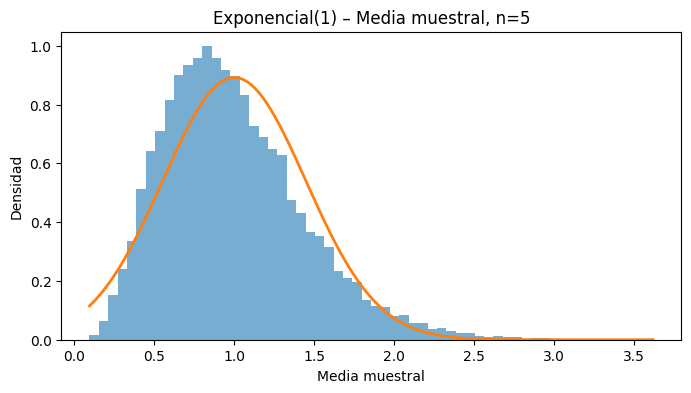

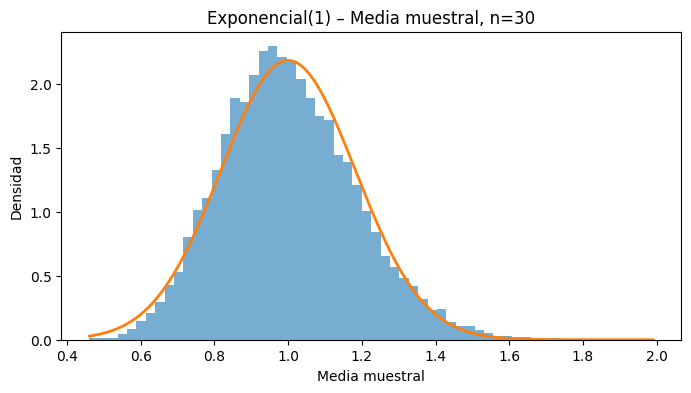

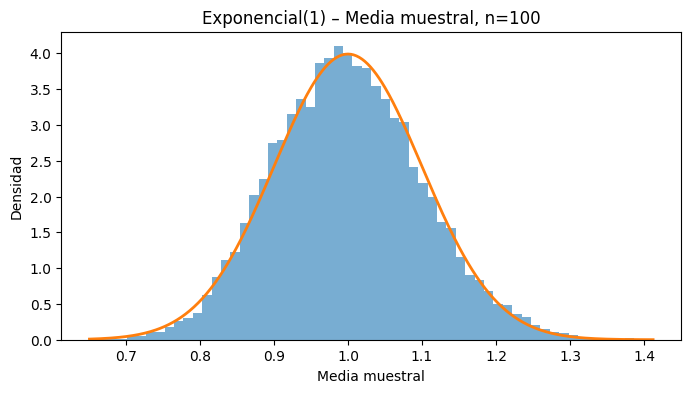

In [9]:
rng_e = np.random.default_rng(42)

# Parámetros teóricos Exponencial(1)
mu_e = 1
sigma_e = 1

R = 20000  # repeticiones Monte Carlo

for n in [5,30, 100]:

    # 1) Simulación directa de R muestras de tamaño n
    X = rng_e.exponential(scale=1.0, size=(R, n))

    # 2) Medias muestrales
    means = X.mean(axis=1)

    # 3) Eje x para la normal teórica
    x = np.linspace(means.min(), means.max(), 400)

    plt.figure(figsize=(8,4))

    # Histograma de medias simuladas
    plt.hist(means, bins=60, density=True, alpha=0.6)

    # 4) Normal teórica según el TLC
    plt.plot(
        x,
        norm.pdf(x, loc=mu_e, scale=sigma_e/np.sqrt(n)),
        linewidth=2
    )

    plt.title(f"Exponencial(1) – Media muestral, n={n}")
    plt.xlabel("Media muestral")
    plt.ylabel("Densidad")
    plt.show()

<div style="background-color:#fff4e5; border-left:4px solid #f5a623; padding:10px; margin:10px 0;">

**Observación importante**

Si bien el Teorema del Límite Central garantiza la convergencia de la distribución
de la media muestral hacia una normal, es importante notar que no existe un tamaño
de muestra n “mágico” a partir del cual esta aproximación sea exacta.  
La **velocidad de convergencia** depende de la distribución original de la variable
aleatoria, en particular de su asimetría y dispersión.

</div>



Para verificar el TLC de forma más formal, se estandariza la media muestral:

$$
Z = \frac{\bar{X}-\mu}{\sigma/\sqrt{n}}
$$

Si el TLC se cumple, entonces $Z$ debe aproximarse a una distribución
normal estándar $\mathcal{N}(0,1)$.


Para verificar esto, realizamos el siguiente procedimiento

In [10]:
rng_e = np.random.default_rng(42)

# Tamaño de muestra
n = 50

# Parámetros teóricos Exponencial(1)
mu_e = 1
sigma_e = 1

R = 30000  # repeticiones Monte Carlo

# 1) Generar las muestras
X = rng_e.exponential(scale=1.0, size=(R, n))

# 2) Medias muestrales
means = X.mean(axis=1)

# 3) Estandarización (TLC)
Z = (means - mu_e) / (sigma_e / np.sqrt(n))


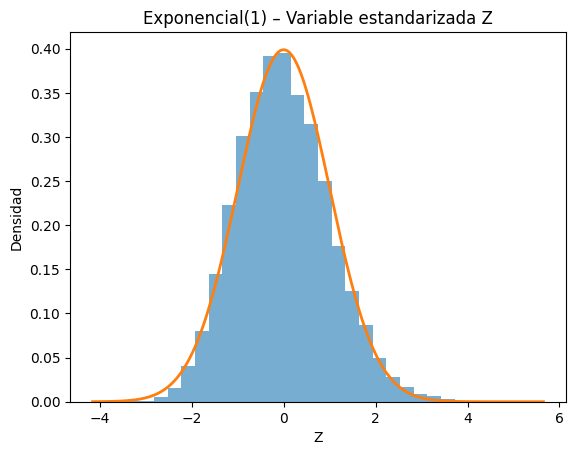

In [11]:
#Visualización
plt.hist(Z, bins=30, density=True, alpha=0.6)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 200)
plt.plot(x, norm.pdf(x, 0, 1), linewidth=2)

plt.title("Exponencial(1) – Variable estandarizada Z")
plt.xlabel("Z")
plt.ylabel("Densidad")
plt.show()

## Resumen

1. **El TLC es sobre promedios, no sobre datos.** $M$ no es Normal y nunca lo será; su promedio $\bar M_k$ sí se aproxima a una Normal cuando $k$ crece.
2. **Sirve para cuantificar incertidumbre.** Es lo que permite pasar de "estimé 4.67" a "estimé 4.67, y el valor real está entre 4.12 y 5.22 con 95% de confianza".
3. **"95% de confianza" es una propiedad del procedimiento, no de un intervalo.** Lo comprobamos construyendo 20.000 intervalos y contando cuántos contienen el valor real.
4. **Es una aproximación, y su calidad depende de la distribución de partida.** Con el máximo de dos dados y $k=30$, un intervalo "del 95%" cubría el 93.7%; con la proporción de no conformes, el 95.0%. No existe un $k$ mágico.
5. **Usar $t$ en vez de $z$** cuando $\sigma$ es desconocida ensancha el intervalo y mejora la cobertura.

### Para la próxima semana

Cerramos el módulo de fundamentos. A partir de la semana 4 pasamos a **simulación de eventos discretos** con SimPy: en lugar de generar muestras independientes, vamos a construir sistemas que evolucionan en el tiempo —colas, servidores, inventarios— y a medir su desempeño. Todo lo de hoy vuelve a aparecer allá, porque cada métrica que estimemos va a necesitar réplicas e intervalos.